In [18]:
import random
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

words = open('names.txt', 'r').read().splitlines()

In [2]:
# So the paper is predicting the next word - we will be predicting the next character
# In paper, model embedds 17,000 words into 30 dimensional vector space which encodes he meaning of words
# model tries to simultaneously learn the word feature vectors and the parameters of that probability function
# So I think this means learn the position of the word vector in that space
# as well as learn the actual space dimensions??? so this reminds me of PCA: what dimensions carry the most variability / information about the word's meaning?

In [3]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [23]:
block_size = 3 # context length: how many previous chars do we use to predict the next?
X, Y = [], [] # X are the nn inputs, Y are the labels for each example in X
for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix] # crop and append (so this just shifts the context down by one character so that we eventually get all 3 consecutive char groups for each word, starting with ...)

X = torch.tensor(X)
Y = torch.tensor(Y)

print(X, Y)
print(X.shape, X.dtype, Y.shape, Y.dtype)

tensor([[ 0,  0,  0],
        [ 0,  0, 20],
        [ 0, 20,  1],
        ...,
        [ 0, 10,  5],
        [10,  5,  1],
        [ 5,  1, 14]]) tensor([20,  1, 21,  ...,  1, 14,  0])
torch.Size([228146, 3]) torch.int64 torch.Size([228146]) torch.int64


In [6]:
# Construct Embedding: the look-up table C
# this the look-up table is how we get the parameters of each char (the parameters representing the semantic meaning of words in the paper)
# We will embed the 27 chars into a 2D space
# or are we embedding all examples (X.shape[0] = 228146) into a 2D space?

C = torch.randn((27, 2))
emb = C[X]
print(emb.shape)
print(C.shape)
# So I believe this means that we have 228146 context examples in X, each of which is list of 3 numbers
# and we have now embedded each into a 2D vector space
print(X[13, 2]) # this is the 2nd number (index of char) in the 13th context input example
print(C[X][13, 2]) # this is the 2D embedding vector of that ^ char
# and we see..
print(C[1])

torch.Size([228146, 3, 2])
torch.Size([27, 2])
tensor(1)
tensor([-0.6356, -0.3969])
tensor([-0.6356, -0.3969])


In [7]:
# Construct Hidden Activation Layer (the nonlinearity, tanh)
# Number of inputs to this layer is 3*2 (from emb because we have 3 previous characters, each as a 2D vector)
# Number of neurons in this layer is a hyperparameter (up to us, can be optimized)

W1 = torch.randn((6, 100)) # weights
b1 = torch.randn(100) # biases

# vid 3, around 26 minutes
# we want to concatenate the three previous context char embeddings into a single 6D vector so that we can perform a forward pass
# torch.cat(torch.unbind(emb, 1), 1) # THESE LINES GIVE THE SAME RESULT
# emb.view(X.shape[0], 6) # THESE LINES GIVE THE SAME RESULT but this one is cheaper due to PyTorch's memory managament

# Thus, hidden layer:
h = torch.tanh(emb.view(emb.shape[0], 6) @ W1 + b1)

In [8]:
# Final Layer: (Softmax) Output Layer
W2 = torch.randn((100, 27)) # weights of layer
b2 = torch.randn(27) # biases of layer

logits = h @ W2 + b2 # forward pass into this layer
counts = logits.exp() # apply softmax activation onto layer output
prob = counts / counts.sum(1, keepdim=True) # apply softmax activation onto layer output
prob.shape

torch.Size([228146, 27])

In [9]:
# Loss (NLL of the Training Data as Predicted by the NN)
# prob[torch.arange(X.shape[0]), Y] is indexing into prob matrix (tensor) and getting the prob that the model assigned to the actual output Y for every example
loss = -prob[torch.arange(X.shape[0]), Y].log().mean()

In [28]:
# =============== WRITTEN NICELY AND OPTIMIZED =======================

In [104]:
# Built dataset

def build_dataset(words):
    block_size = 3 # context length: how many previous chars do we use to predict the next?
    X, Y = [], [] # X are the nn inputs, Y are the labels for each example in X
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append (so this just shifts the context down by one character so that we eventually get all 3 consecutive char groups for each word, starting with ...)

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # training set
Xdev, Ydev = build_dataset(words[n1:n2]) # dev set
Xte, Yte = build_dataset(words[n2:]) # test set


In [105]:
# Construct and Initialize NN

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [106]:
print(sum(p.nelement() for p in parameters)) # total number of parameters in model
lre = torch.linspace(-3, 0, 1000) # learning rate exponent
lrs = 10**lre # learning rates

lrei = []
lossi = []
stepi = []

11897


In [107]:
# Gradient Descent

num_itr = 200000
for i in range(num_itr):
    
    # minibatch construction (for computational speed)
    ix = torch.randint(0, Xtr.shape[0], (32,)) # samples 32 indexes from dataset
    
    # forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
    logits = h @ W2 + b2 # log-counts
    loss = F.cross_entropy(logits, Ytr[ix])
    if i == 0 or i == num_itr - 1:
        print(f'loss at step {i} = {loss.item()}')
    
    # backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    # update parameters
    #lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad
        
    # track states
    #lrei.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())



loss at step 0 = 23.03456687927246
loss at step 199999 = 1.930240511894226


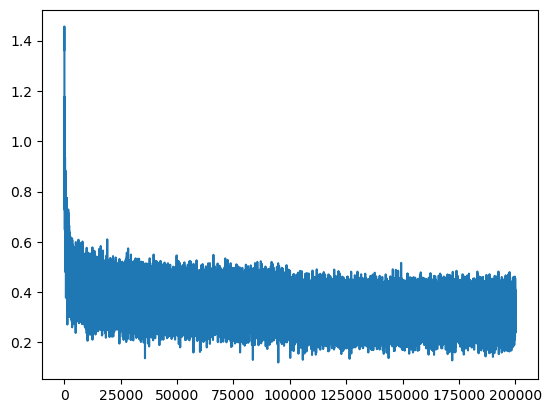

In [108]:
plt.plot(stepi, lossi)

In [ ]:
plt.plot(lrei, lossi)

In [109]:
# eval loss on dev set
emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 # log-counts
loss = F.cross_entropy(logits, Ydev)
print(loss.item())

2.172673463821411


In [110]:
# eval loss on training set
# if the performance on the training/dev set differs from on that test set, this implies overfitting to training / dev set

emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2 # log-counts
loss = F.cross_entropy(logits, Ytr)
print(loss.item())

2.122694969177246


In [16]:
# training split, dev/validation split, test split
# 80%, 10%, 10%
# training set: used to train model parameters
# dev set: used to train model hyperparameters
# test set: used to evaluate model performance after all training (don't want to train on this to prevent overfitting)

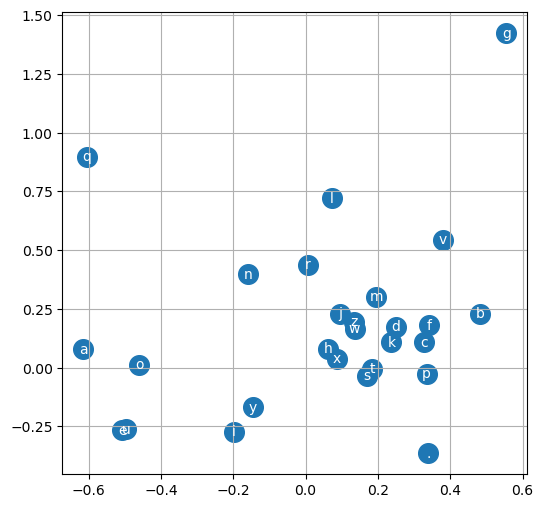

In [ ]:
# visualize embedding vectors (2D case) that have been learned
plt.figure(figsize=(6,6))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [95]:
# Production Workflow:
# run experiments on dev set to find optimal hyperparameters
# train model on training set with these hyperparameters
# evaluate model loss on test set a single time at the end - this is the loss you report

In [ ]:
# Sample from the Model

g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with ...
    while True:
        emb = C[torch.tensor([context])] # embed the current context
        h = torch.tanh(emb.view(1,-1) @ W1 + b1) # project embedding into the hidden layer (latent space)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1) # get prob distribution
        ix = torch.multinomial(probs, num_samples=1, generator=g).item() # sample index of next char from prob distribution
        context = context[1:] + [ix] # shift context window
        out.append(ix)
        if ix == 0:
            break

    print(''.join(itos[i] for i in out))

carmah.
amoriq.
khi.
mish.
taty.
salaysleer.
hutlfredirra.
kaqui.
ner.
kia.
chaiivia.
leggys.
bron.
cadessanis.
lilea.
jadbi.
wazelo.
dearyxi.
jaxeenivudh.
edde.
